In [3]:
import pandas as pd
import seaborn as sns
#library for visualizing data in python (histograms)
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="darkgrid")

In [4]:
df = pd.read_csv("music_streams.csv")
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [5]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='str')

In [6]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


In [7]:
len(df["label"].unique())

13

## Histogram
### Monthly streams histogram

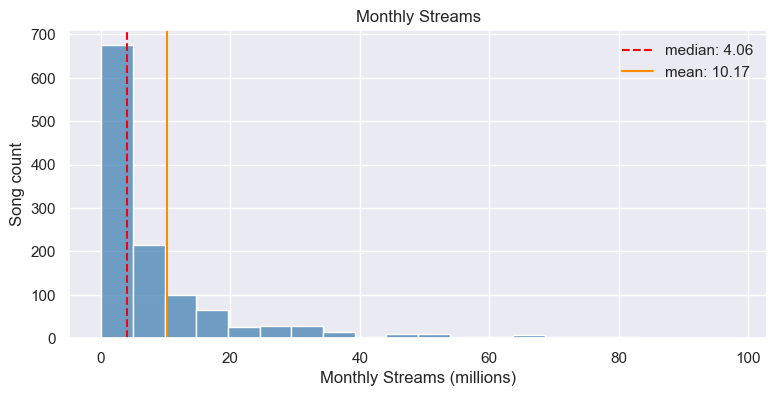

In [8]:
fig, ax = plt.subplots(figsize=(9,4))

median = df.streams_millions.median()
mean = df.streams_millions.mean()

#Dataset has some outliers
#Vast majority of streams are less than 500 mil
# so instead of sns.histplot(data=df, x="streams_millions", bins=20):
sns.histplot(data=df[df.streams_millions < 100], x="streams_millions", bins=20, ax=ax, color="steelblue")

# create vertical line and pass the median/mean to it
ax.axvline(median, label=f"median: {median:.2f}", color="red", linestyle="--")
ax.axvline(mean, label=f"mean: {mean:.2f}", color="darkorange")
ax.legend(frameon=False) #remove frame of legend/create it

ax.set_xlabel('Monthly Streams (millions)')
ax.set_ylabel('Song count')
ax.set_title("Monthly Streams")

plt.show()

#### Python function version


In [9]:
# Pass 'df' into the function so it doesn't rely on global variables
def createHistogram(df, columnName, filterData=False): 

    # Start with the original dataframe
    tempdf = df
    
    # Corrected the bracket placement and variable casing
    if filterData:
        tempdf = df[df[columnName] < 100]

    fig, ax = plt.subplots(figsize=(9, 4))

    # Use bracket notation instead of dot notation
    median = tempdf[columnName].median()
    mean = tempdf[columnName].mean()

    # Use 'tempdf' and the 'columnName' variable properly inside histplot
    sns.histplot(data=tempdf, x=columnName, bins=20, ax=ax, color="steelblue")

    # Create vertical lines
    ax.axvline(median, label="median", color="red", linestyle="--")
    ax.axvline(mean, label="mean", color="darkorange")
    ax.legend(frameon=False) 

    ax.set_xlabel(columnName)
    ax.set_ylabel('Song count')
    ax.set_title(f"Monthly Streams ({columnName})")

    plt.show()

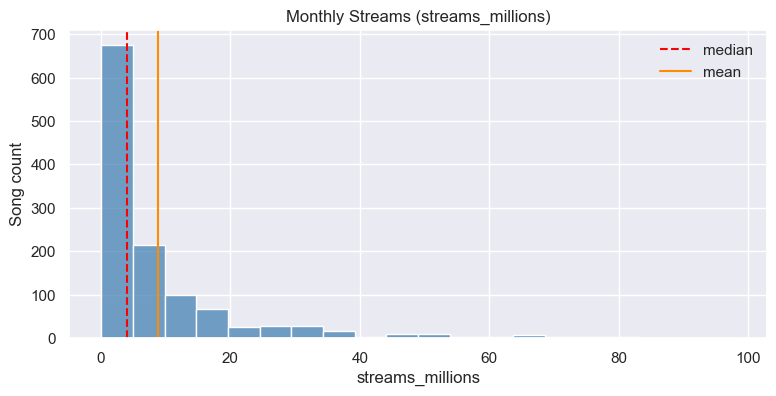

In [10]:
createHistogram(df, "streams_millions", filterData=True)

## Boxplots

In [11]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=False).index

order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='str', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

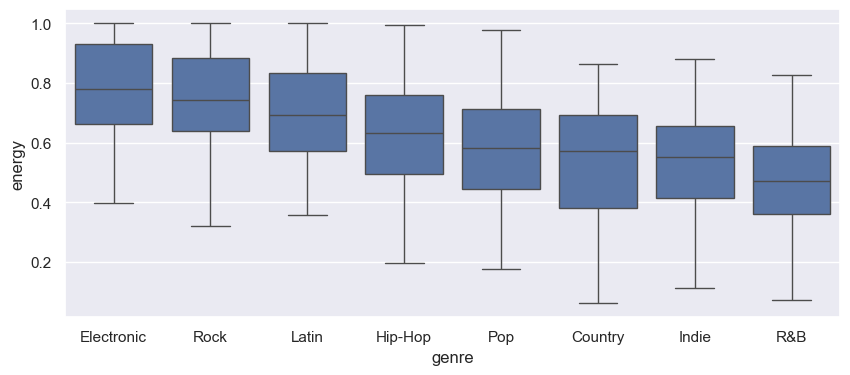

In [12]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df, y="energy", x="genre", order=order, ax=ax)

<Axes: xlabel='streams_millions', ylabel='label'>

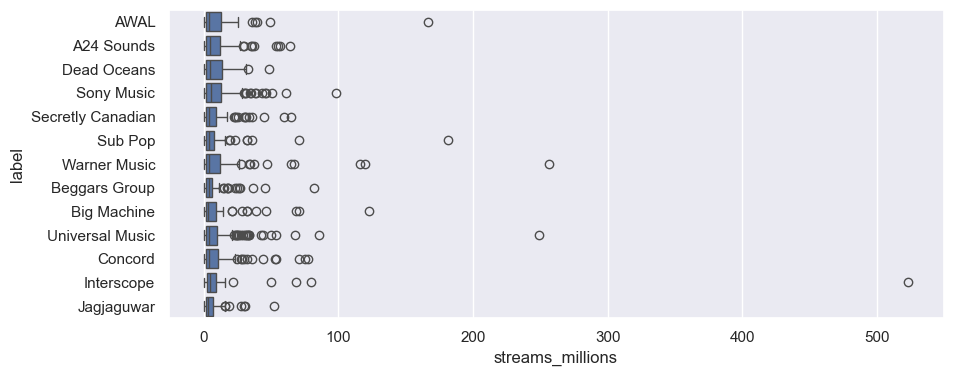

In [13]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df, y="label", x="streams_millions", ax=ax)

### Apply logs to unsquish data

#### Before

<Axes: xlabel='genre', ylabel='monthly_listeners'>

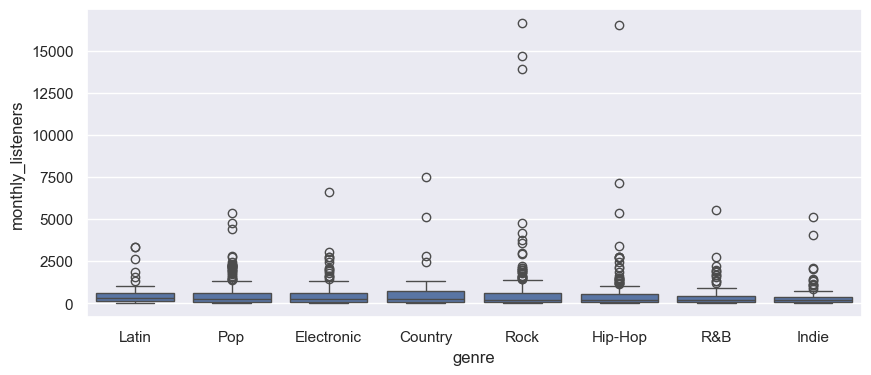

In [14]:
order = df.groupby("genre")["monthly_listeners"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df, y="monthly_listeners", x="genre", order=order, ax=ax)

#### After

In [15]:
df["monthly_listeners_log"] = np.log(df["monthly_listeners"])

<Axes: xlabel='genre', ylabel='monthly_listeners_log'>

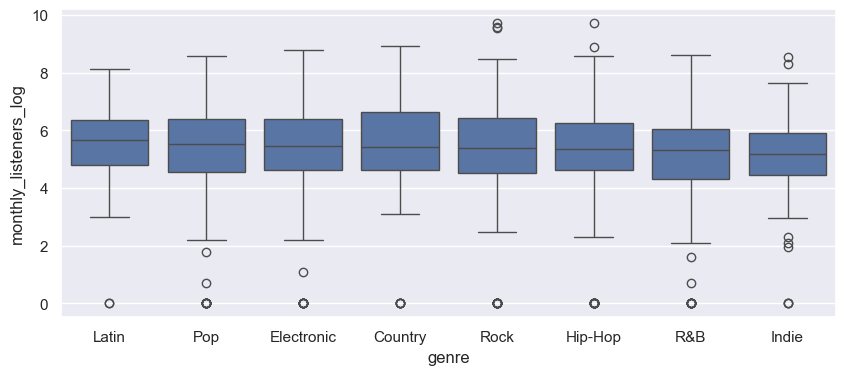

In [16]:
order = df.groupby("genre")["monthly_listeners"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df, y="monthly_listeners_log", x="genre", order=order, ax=ax)
# ax.set_yscale('log, base=2) to skip the log step before

### Scatterplot

<Axes: xlabel='energy', ylabel='danceability'>

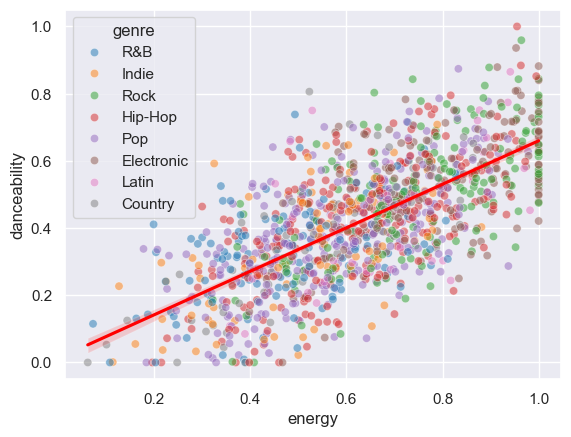

In [17]:
sample = df.sample(600)
sns.scatterplot(data=df, x="energy", y="danceability", hue="genre", palette="tab10", color="grey", alpha=0.5)
sns.regplot(data=df, x="energy", y="danceability", scatter=False, color="red")

#### Small multiples for better readability

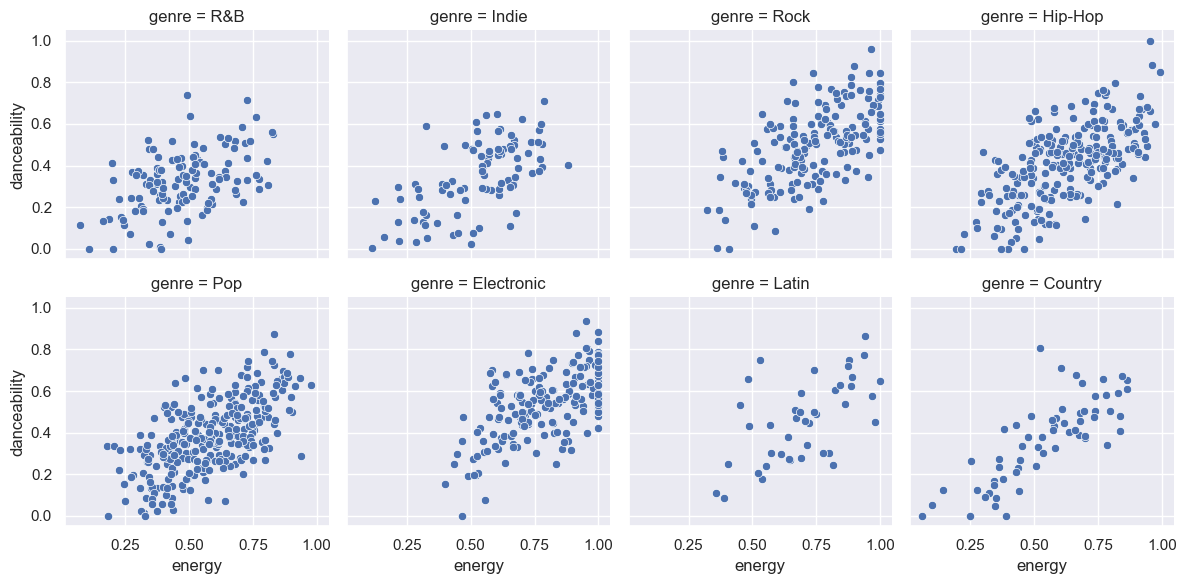

In [18]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")

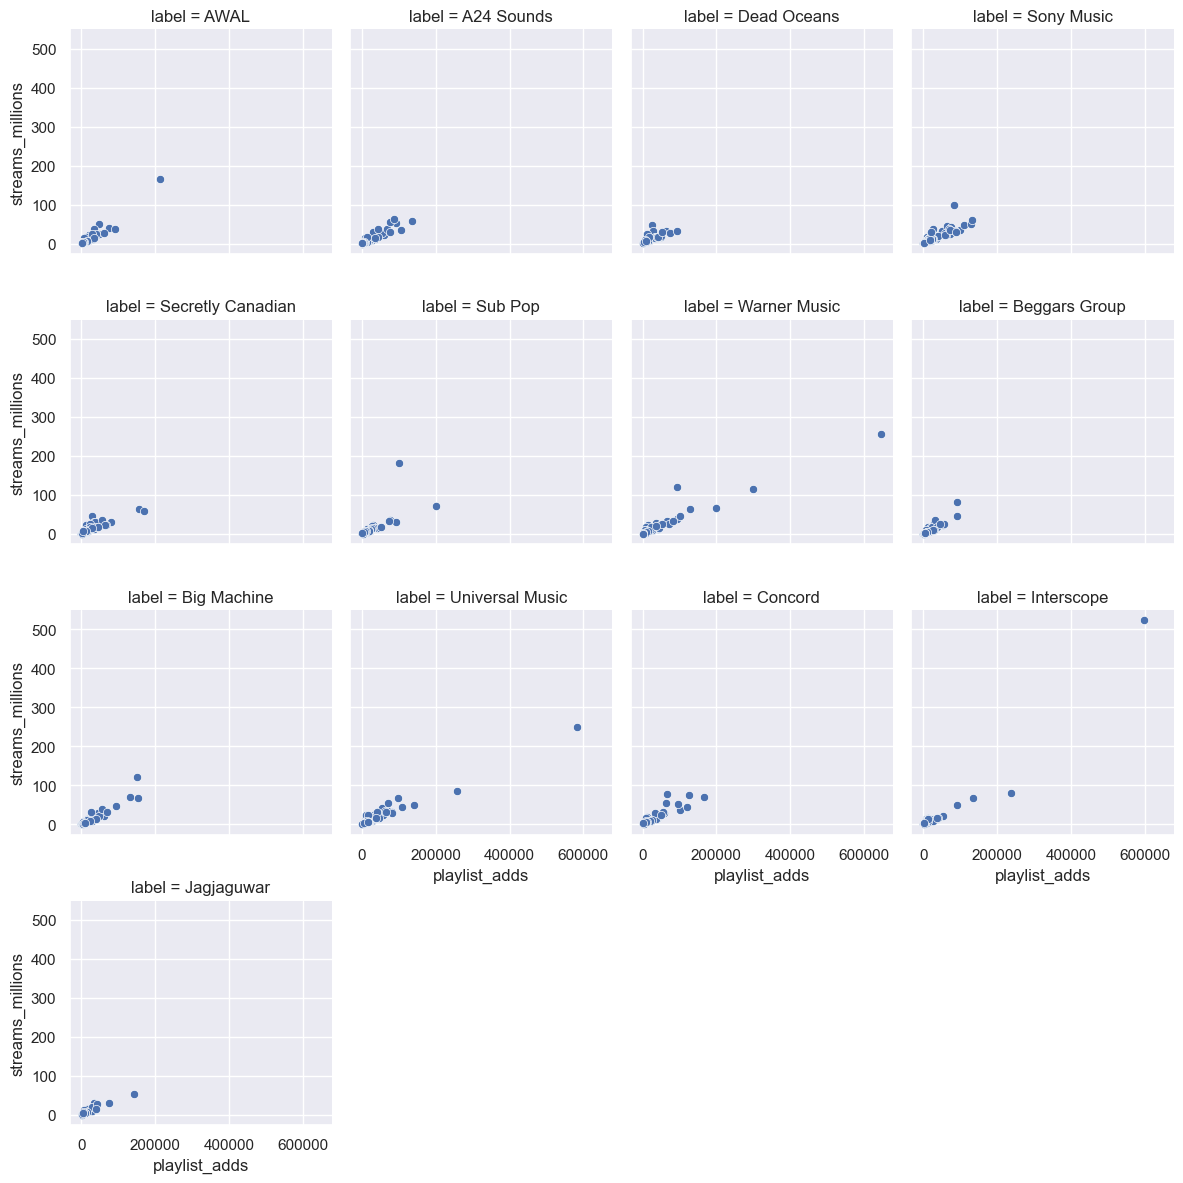

In [19]:
g = sns.FacetGrid(df, col="label", col_wrap=4)
g.map(sns.scatterplot, "playlist_adds", "streams_millions")

### Line charts and friends

In [20]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [21]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].median()
pop_trend

year
2015     7.160
2016     3.540
2017     3.560
2018    11.370
2019     4.720
2020     5.075
2021     3.645
2022     4.445
2023     4.230
2024     3.390
Name: streams_millions, dtype: float64

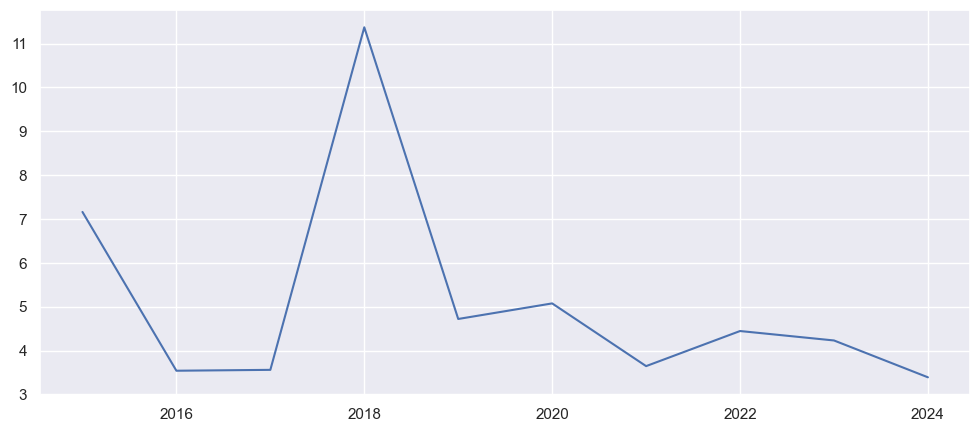

In [22]:
fig, ax = plt.subplots(figsize=(12,5))
# do index to chart pop trends by recorded year
ax.plot(pop_trend.index, pop_trend)

In [29]:
df.genre.unique()
genres = ["Pop","Indie","Hip-Hop"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median()
#to ungroup add .reset_index() at the end

print(trend)
# median value of each millions of streams by genre by year

# fig, axes = plt.subplots(2,3,figsize=(12,5))
# [i for i in zip(axes, genres)]

year  genre  
2015  Hip-Hop     5.755
      Indie      13.900
      Pop         7.160
2016  Hip-Hop     5.650
      Indie       3.720
      Pop         3.540
2017  Hip-Hop     4.660
      Indie       2.130
      Pop         3.560
2018  Hip-Hop     4.590
      Indie       6.385
      Pop        11.370
2019  Hip-Hop     3.080
      Indie       2.380
      Pop         4.720
2020  Hip-Hop     3.285
      Indie       4.365
      Pop         5.075
2021  Hip-Hop     4.155
      Indie       3.410
      Pop         3.645
2022  Hip-Hop     4.200
      Indie       5.480
      Pop         4.445
2023  Hip-Hop     3.670
      Indie       2.380
      Pop         4.230
2024  Hip-Hop     5.010
      Indie       3.420
      Pop         3.390
Name: streams_millions, dtype: float64


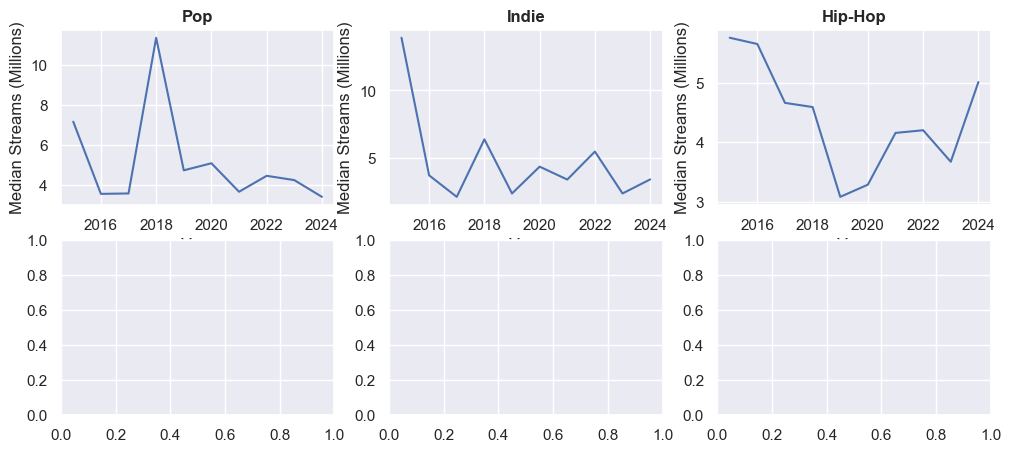

In [ ]:
genres = ["Pop","Indie","Hip-Hop"]
trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()
fig, axes = plt.subplots(2,3,figsize=(12,5))
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions)
    ax.set_title(genre, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Median Streams (Millions)")

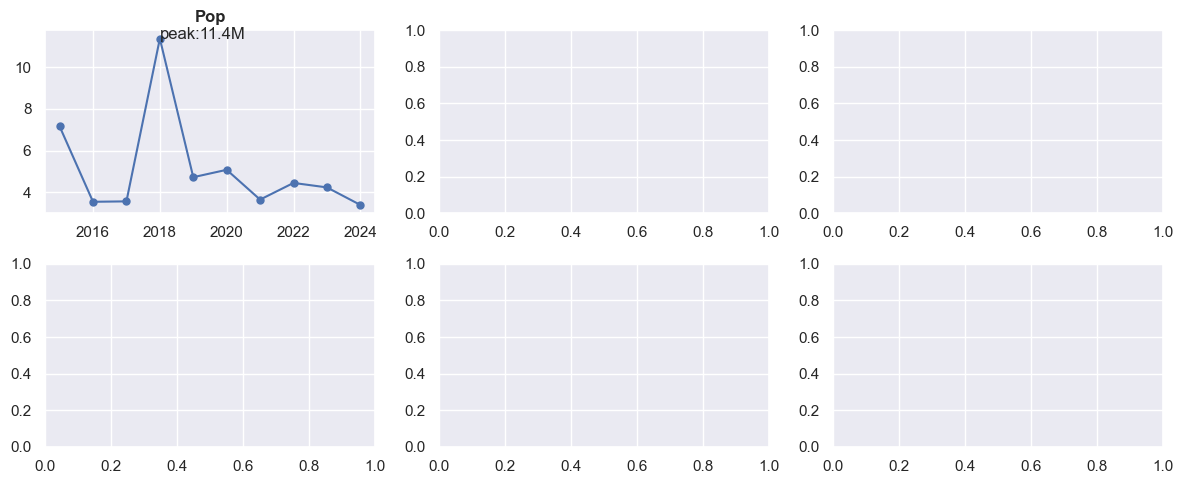

In [ ]:
genres = ["Pop","Indie","Hip-Hop", "Rock"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(12, 5), tight_layout=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    #gives us the peak
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    peak = subD.loc[subD.streams_millions.idxmax()]
    # annotate the peak, the x and y are by year and millions
    ax.annotate(f"peak:{peak.streams_millions:.1f}M", xy=(peak.year, peak.streams_millions))
    ax.set_title(genre, fontweight="bold")
    break
    ax.plot(subD.year, subD.streams_millions)
    ax.set_title(genre, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Median Streams (Millions)")

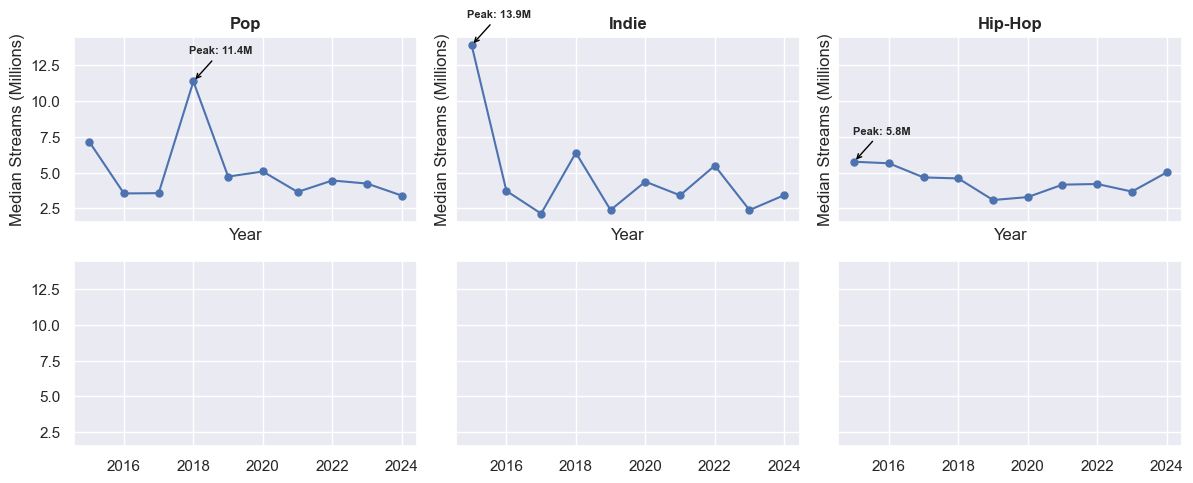

In [ ]:
import matplotlib.pyplot as plt

genres = ["Pop", "Indie", "Hip-Hop"]
trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True, tight_layout=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    ax.annotate(
            f"Peak: {peak.streams_millions:.1f}M", 
            xy=(peak.year, peak.streams_millions),          # (x, y) coordinates
            textcoords="offset points",                     # Offsets text relative to the point
            xytext=(20, 20),                                # Moves text 20 points above the dot
            ha='center',                                    # Centers text horizontally
            fontsize=8,
            arrowprops=dict(arrowstyle="->", color="black", lw=1),
            fontweight="bold",
        )
    ax.set_title(genre, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Median Streams (Millions)")

plt.show()

## Lab Task 3 - Visualization
### Line chart

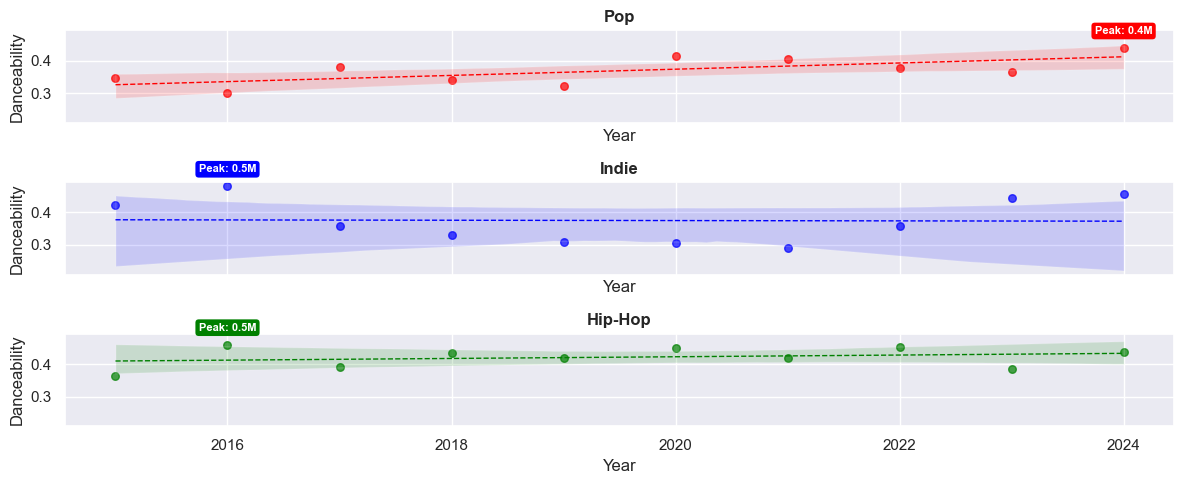

In [ ]:
import matplotlib.pyplot as plt

genres = ["Pop", "Indie", "Hip-Hop"]
trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["danceability"].median().reset_index()
colors = ["red", "blue", "green"]

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True, sharey=True, tight_layout=True)
axes = axes.flatten()

for ax, genre, color in zip(axes, genres, colors):
    subD = trend[trend.genre == genre]
    peak = subD.loc[subD.danceability.idxmax()]
    sns.set_style("darkgrid", {"grid.color": ".8"})
    sns.regplot(
        x="year", 
        y="danceability", 
        data=subD, 
        ax=ax,
        color=color,
        scatter_kws={"s": 30, "alpha": 0.7},  # dots
        line_kws={"lw": 1, "linestyle": "--"} # line
    )
    ax.annotate(
            f"Peak: {peak.danceability:.1f}M", 
            xy=(peak.year, peak.danceability),          
            textcoords="offset points",                     
            xytext=(0, 10),                                
            ha='center',                                    
            fontsize=8,
            fontweight="bold",
            color='white',
            bbox=dict(boxstyle="round,pad=0.3", fc=color, alpha=1, ec="none")
        )
    ax.set_title(genre, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Danceability")

plt.show()

### Altair Chart

In [32]:
import altair as alt
df = pd.read_csv("music_streams.csv")

chart = alt.Chart(df).mark_point(size=60).encode(
    x='danceability:Q',              
    y='streams_millions:Q',  
    color='genre:N',
    tooltip=['genre', 'label']
).interactive()

chart.show()

alt.Chart(...)